# **Clasificador de imágenes: Modelo 2**
---

Autores: Andrés Barroso Soriano y Paula Santana García

Universidad de Las Palmas de Gran Canaria, Curso 2025 - 2026

#### **CAMBIOS RESPECTO AL MODELO ANTERIOR**

Hemos añadido una capa convolutiva más.
También habíamos añadido dropout ligero pero debido a que afectaba negativamente lo hemos acabado eliminando.

#### **RESULTADOS OBTENIDOS**
Podemos observar que, con solo añadir una red convolutiva más alcanza un  accuracy del 53.44 %. Es decir, que mejora el accuracy en un 8 %

Saving dataset4.zip to dataset4.zip
Total imágenes: 651
Entrenamiento: 455
Validación: 65
Prueba: 131
Clases: ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']
Epoch [1/20] - Train Loss: 1.8100, Train Acc: 14.29% | Val Loss: 1.8073, Val Acc: 15.38%
Epoch [2/20] - Train Loss: 1.7898, Train Acc: 17.14% | Val Loss: 1.7944, Val Acc: 24.62%
Epoch [3/20] - Train Loss: 1.7813, Train Acc: 22.20% | Val Loss: 1.7717, Val Acc: 29.23%
Epoch [4/20] - Train Loss: 1.7071, Train Acc: 33.41% | Val Loss: 1.6704, Val Acc: 40.00%
Epoch [5/20] - Train Loss: 1.5331, Train Acc: 34.29% | Val Loss: 1.4606, Val Acc: 36.92%
Epoch [6/20] - Train Loss: 1.2978, Train Acc: 48.35% | Val Loss: 1.7156, Val Acc: 36.92%
Epoch [7/20] - Train Loss: 1.0737, Train Acc: 55.60% | Val Loss: 1.3443, Val Acc: 38.46%
Epoch [8/20] - Train Loss: 0.8611, Train Acc: 66.81% | Val Loss: 1.6730, Val Acc: 29.23%
Epoch [9/20] - Train Loss: 0.6249, Train Acc: 77.14% | Val Loss: 1.8380, Val Acc: 40.00%
Epoch [10/20] - Train Loss: 0.4025,

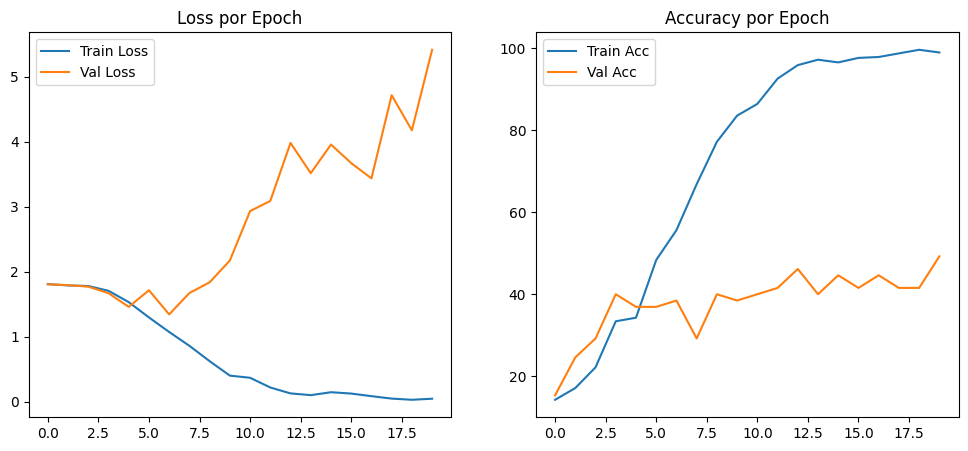


Accuracy en test: 49.62%


<Figure size 700x600 with 0 Axes>

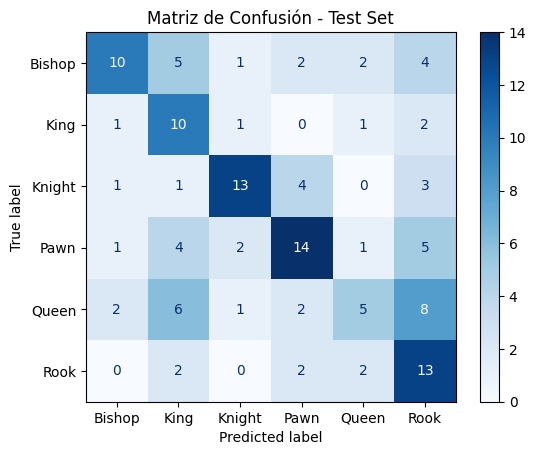

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import os, zipfile
from google.colab import files
import numpy as np
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =============================
# SEMILLA
# =============================
def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
    random.seed(seed)

seed_everything(42)

# =============================
# SUBIR Y EXTRAER DATASET
# =============================
uploaded = files.upload()
with zipfile.ZipFile("dataset4.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset4")

# =============================
# TRANSFORMACIONES
# =============================
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# =============================
# CARGA DEL DATASET
# =============================
dataset = datasets.ImageFolder(root="dataset4/dataset4", transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

print(f"Total imágenes: {len(dataset)}")
print(f"Entrenamiento: {len(train_data)}")
print(f"Validación: {len(val_data)}")
print(f"Prueba: {len(test_data)}")
print(f"Clases: {dataset.classes}")

# =============================
# DEFINICIÓN DE LA RED NEURONAL
# =============================
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# =============================
# ENTRENAMIENTO
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 20
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    # ----- Entrenamiento -----
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / otal_traint

    # ----- Validación -----
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, "
          f"Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# =============================
# GRAFICAS
# =============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.title('Loss por Epoch')

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.title('Accuracy por Epoch')
plt.show()

# =============================
# TEST
# =============================
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'\nAccuracy en test: {100 * correct / total:.2f}%')

# =============================
# MATRIZ DE CONFUSIÓN
# =============================
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)

plt.figure(figsize=(7,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Test Set")
plt.show()
